Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

from sklearn.utils import resample

sns.set(style="whitegrid", context="notebook")

DATA_PATH = Path("./diabetic_data.csv")

Load Data & Basic EDA

- distributions, missingness, target balance.

Raw shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



Column types:
encounter_id                 int64
patient_nbr                  int64
race                        object
gender                      object
age                         object
weight                      object
admission_type_id            int64
discharge_disposition_id     int64
admission_source_id          int64
time_in_hospital             int64
payer_code                  object
medical_specialty           object
num_lab_procedures           int64
num_procedures               int64
num_medications              int64
number_outpatient            int64
number_emergency             int64
number_inpatient             int64
diag_1                      object
diag_2                      object
diag_3                      object
number_diagnoses             int64
max_glu_serum               object
A1Cresult                   object
metformin                   object
repaglinide                 object
nateglinide                 object
chlorpropamide              object
glime

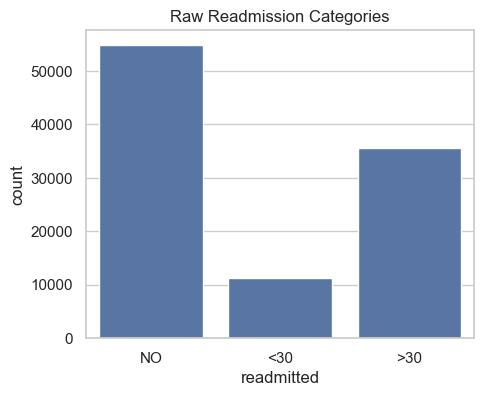


Number of '?' per column:
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
tolbutamide              0
pioglitazone             0
rosiglitazone            0
acarbose                 0
miglitol                 0
dtype: int64


In [3]:

df_raw = pd.read_csv(DATA_PATH)
print("Raw shape:", df_raw.shape)
display(df_raw.head())

print("\nColumn types:")
print(df_raw.dtypes)

print("\nBasic info:")
print(df_raw.info())

# Target distribution (raw)
print("\nRaw 'readmitted' value counts:")
print(df_raw['readmitted'].value_counts(dropna=False))

plt.figure(figsize=(5,4))
sns.countplot(x='readmitted', data=df_raw, order=['NO','<30','>30'])
plt.title("Raw Readmission Categories")
plt.show()

# Check missing / '?' frequencies
missing_summary = (df_raw == "?").sum().sort_values(ascending=False)
print("\nNumber of '?' per column:")
print(missing_summary.head(15))


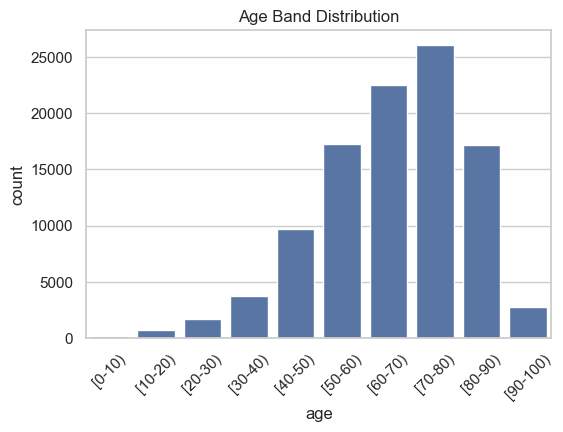

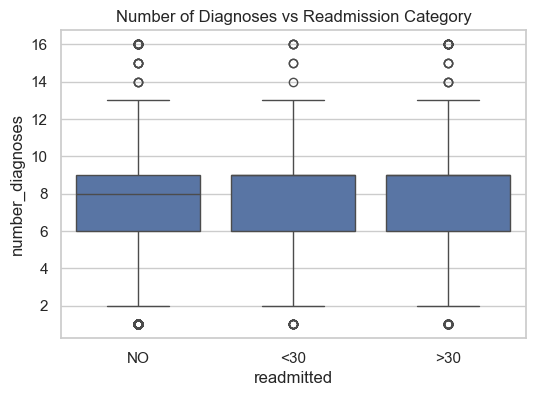

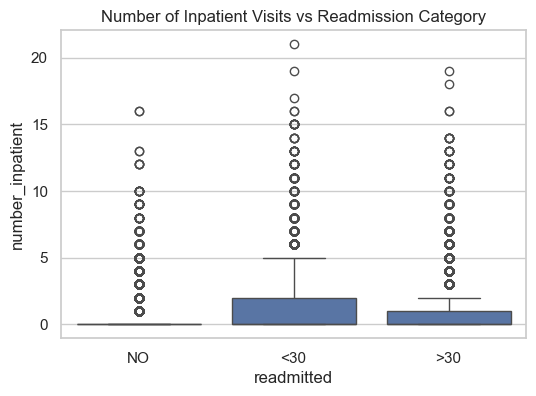

In [4]:
# Age band distribution
plt.figure(figsize=(6,4))
sns.countplot(x='age', data=df_raw,
              order=["[0-10)","[10-20)","[20-30)","[30-40)","[40-50)",
                     "[50-60)","[60-70)","[70-80)","[80-90)","[90-100)"])
plt.xticks(rotation=45)
plt.title("Age Band Distribution")
plt.show()

# Number of diagnoses vs readmission
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='number_diagnoses', data=df_raw,
            order=['NO','<30','>30'])
plt.title("Number of Diagnoses vs Readmission Category")
plt.show()

# Number of inpatient visits vs readmission
plt.figure(figsize=(6,4))
sns.boxplot(x='readmitted', y='number_inpatient', data=df_raw,
            order=['NO','<30','>30'])
plt.title("Number of Inpatient Visits vs Readmission Category")
plt.show()


Preprocessing & Feature Engineering

- This function encodes everything into a numeric X and binary y (30-day readmission).

In [5]:

def preprocess_diabetes(path="./diabetic_data.csv", target="30"):
    """
    Preprocess the Diabetes 130-US Hospitals dataset.

    target="30"  -> predict 30-day readmission (<30 vs {NO, >30})
    target="any" -> predict any readmission ({<30, >30} vs NO)
    """
    df = pd.read_csv(path)
    df = df.replace("?", np.nan)

    # Drop invalid gender
    df = df[df['gender'] != 'Unknown/Invalid']

    # Drop discharge dispositions that imply death / hospice
    drop_disp = [11, 13, 14, 19, 20, 21]
    df = df[~df['discharge_disposition_id'].isin(drop_disp)]

    # Drop identifiers and high-missing columns
    df = df.drop(columns=['encounter_id',
                          'patient_nbr',
                          'weight',
                          'payer_code',
                          'medical_specialty'])

    # Fill race with mode
    df['race'] = df['race'].fillna(df['race'].mode()[0])

    # Map age bands to integers
    age_map = {"[0-10)":0,"[10-20)":1,"[20-30)":2,"[30-40)":3,"[40-50)":4,
               "[50-60)":5,"[60-70)":6,"[70-80)":7,"[80-90)":8,"[90-100)":9}
    df['age'] = df['age'].map(age_map).astype('int8')

    # Gender: Female=0, Male=1
    df['gender'] = df['gender'].map({'Female':0,'Male':1}).astype('int8')

    # A1Cresult: encode severity + special code for missing/None
    df['A1Cresult'] = df['A1Cresult'].map({'Norm':0,'>7':1,'>8':2,'None':-1}).fillna(-1).astype('int8')

    # max_glu_serum
    df['max_glu_serum'] = df['max_glu_serum'].map({'Norm':0,'>200':1,'>300':2,'None':-1}).fillna(-1).astype('int8')

    # Group ICD-9 codes into coarse categories
    def icd_group(x):
        try:
            x = float(x)
        except:
            return 8
        if 390 <= x <= 459 or x == 785: return 0   # circulatory
        if 460 <= x <= 519 or x == 786: return 1   # respiratory
        if 520 <= x <= 579 or x == 787: return 2   # digestive
        if 250 <= x < 251:               return 3   # diabetes
        if 800 <= x <= 999:             return 4   # injury/poisoning
        if 710 <= x <= 739:             return 5   # musculoskeletal
        if 580 <= x <= 629 or x == 788: return 6   # genitourinary
        if 140 <= x <= 239:             return 7   # neoplasms
        return 8                                     # other/unknown

    for col in ['diag_1', 'diag_2', 'diag_3']:
        df[col] = df[col].apply(icd_group).astype('int8')

    # Encode diabetes medications as 0/1 (any use)
    med_cols = [
        'metformin','repaglinide','nateglinide','chlorpropamide',
        'glimepiride','acetohexamide','glipizide','glyburide',
        'tolbutamide','pioglitazone','rosiglitazone','acarbose',
        'miglitol','troglitazone','tolazamide','insulin',
        'glyburide-metformin','glipizide-metformin',
        'glimepiride-pioglitazone','metformin-rosiglitazone',
        'metformin-pioglitazone','examide','citoglipton'
    ]
    for col in med_cols:
        df[col] = df[col].map({'No':0,'Steady':1,'Up':1,'Down':1}).fillna(0).astype('int8')

    # Treatment flags
    df['diabetesMed'] = df['diabetesMed'].map({'No':0,'Yes':1}).astype('int8')
    df['change']      = df['change'].map({'No':0,'Ch':1}).astype('int8')

    # Define target
    if target == "any":
        y = df['readmitted'].replace({'NO':0,'<30':1,'>30':1}).astype('int8')
    elif target == "30":
        y = df['readmitted'].replace({'NO':0,'>30':0,'<30':1}).astype('int8')
    else:
        raise ValueError("target must be 'any' or '30'")

    # Drop original readmitted column from features
    df = df.drop(columns=['readmitted'])

    # One-hot encode race & admin IDs
    df = pd.get_dummies(
        df,
        columns=['race', 'admission_type_id',
                 'discharge_disposition_id',
                 'admission_source_id'],
        drop_first=True
    )

    X = df

    return X, y

# Run preprocessing
X, y = preprocess_diabetes(target="30")  # or "any" if you want any readmission
print("Processed X shape:", X.shape)
print("Target distribution:\n", y.value_counts(normalize=True))


Processed X shape: (99340, 87)
Target distribution:
 readmitted
0    0.886108
1    0.113892
Name: proportion, dtype: float64


C:\Users\aznga\AppData\Local\Temp\ipykernel_30292\880703548.py:82: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = df['readmitted'].replace({'NO':0,'>30':0,'<30':1}).astype('int8')


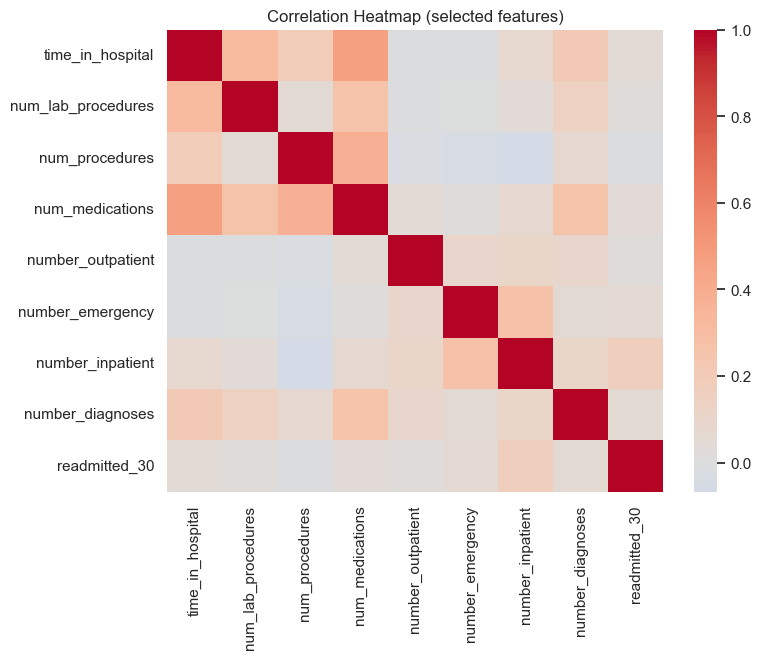

In [6]:
# Simple correlation heatmap for a few numeric features
num_cols_small = ['time_in_hospital', 'num_lab_procedures',
                  'num_procedures', 'num_medications',
                  'number_outpatient', 'number_emergency',
                  'number_inpatient', 'number_diagnoses']

corr = pd.concat([X[num_cols_small], y.rename('readmitted_30')], axis=1).corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (selected features)")
plt.show()


Train/Test Split, Scaling & Balancing

- We’ll use a held-out test set and a downsampled training set for imbalance handling.

In [7]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)

# Downsample majority class in training set
def balance_dataset_downsample(X, y):
    df_train = X.copy()
    df_train['target'] = y.values

    df_majority = df_train[df_train['target'] == 0]
    df_minority = df_train[df_train['target'] == 1]

    df_majority_downsampled = resample(
        df_majority,
        replace=False,
        n_samples=len(df_minority),
        random_state=42
    )

    df_bal = pd.concat([df_majority_downsampled, df_minority])
    df_bal = df_bal.sample(frac=1, random_state=42).reset_index(drop=True)

    y_bal = df_bal['target']
    X_bal = df_bal.drop(columns=['target'])

    return X_bal, y_bal

X_train_bal, y_train_bal = balance_dataset_downsample(X_train, y_train)
print("\nBalanced class counts:\n", y_train_bal.value_counts())

# Standardize all numeric features for models that need it
num_cols = X_train_bal.columns  # all are numeric after preprocessing

scaler = StandardScaler()
X_train_bal_scaled = X_train_bal.copy()
X_test_scaled      = X_test.copy()

X_train_bal_scaled[num_cols] = scaler.fit_transform(X_train_bal_scaled[num_cols])
X_test_scaled[num_cols]      = scaler.transform(X_test_scaled[num_cols])


Train shape: (79472, 87)  Test shape: (19868, 87)

Balanced class counts:
 target
1    9051
0    9051
Name: count, dtype: int64


Helper: Training, Evaluation & Comparison

- Central function to train a model + compute metrics.

In [11]:
# 4. HELPER: TRAIN & EVALUATE

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report
)

def train_and_evaluate(model, X_train, y_train, X_test, y_test, name="Model"):
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    # Get a continuous score for ROC–AUC:
    y_score = None
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    roc  = roc_auc_score(y_test, y_score) if y_score is not None else float("nan")

    print("Accuracy:  ", f"{acc:.3f}")
    print("Precision: ", f"{prec:.3f}")
    print("Recall:    ", f"{rec:.3f}")
    print("F1-score:  ", f"{f1:.3f}")
    print("ROC-AUC:   ", f"{roc:.3f}")

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion matrix:\n", cm)

    print("\nClassification report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    return {
        "model": model,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "roc_auc": roc,
        "cm": cm
    }


def plot_feature_importance(model, feature_names, title):
    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    else:
        return  # nothing to do

    fi = pd.DataFrame({
        "feature": feature_names,
        "importance": importances
    }).sort_values("importance", ascending=False).head(15)

    plt.figure(figsize=(8,6))
    sns.barplot(x="importance", y="feature", data=fi, orient="h")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_model_comparison(results_dict):
    # results_dict: name -> metrics dict
    models = list(results_dict.keys())
    metrics = ["accuracy", "precision", "recall", "f1", "roc_auc"]

    plt.figure(figsize=(10,5))
    x = np.arange(len(models))
    width = 0.15

    for i, metric in enumerate(metrics):
        vals = [results_dict[m][metric] for m in models]
        plt.bar(x + i*width, vals, width=width, label=metric)

    plt.xticks(x + width*2, models, rotation=45)
    plt.ylabel("Score")
    plt.title("Model Comparison")
    plt.legend()
    plt.tight_layout()
    plt.show()


5. Baseline + Advanced Models

- Logistic Regression (baseline)

- Random Forest (advanced tree ensemble)

- SVM with RBF kernel (advanced kernel method)

- Neural Network (MLPClassifier)


=== Logistic Regression (L2, balanced) ===
Accuracy:   0.674
Precision:  0.182
Recall:     0.533
F1-score:   0.272
ROC-AUC:    0.665

Confusion matrix:
 [[12194  5411]
 [ 1057  1206]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.69      0.79     17605
           1       0.18      0.53      0.27      2263

    accuracy                           0.67     19868
   macro avg       0.55      0.61      0.53     19868
weighted avg       0.84      0.67      0.73     19868


=== Random Forest ===
Accuracy:   0.643
Precision:  0.179
Recall:     0.597
F1-score:   0.276
ROC-AUC:    0.668

Confusion matrix:
 [[11433  6172]
 [  913  1350]]

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.65      0.76     17605
           1       0.18      0.60      0.28      2263

    accuracy                           0.64     19868
   macro avg       0.55      0.62      0.52     19868
weig

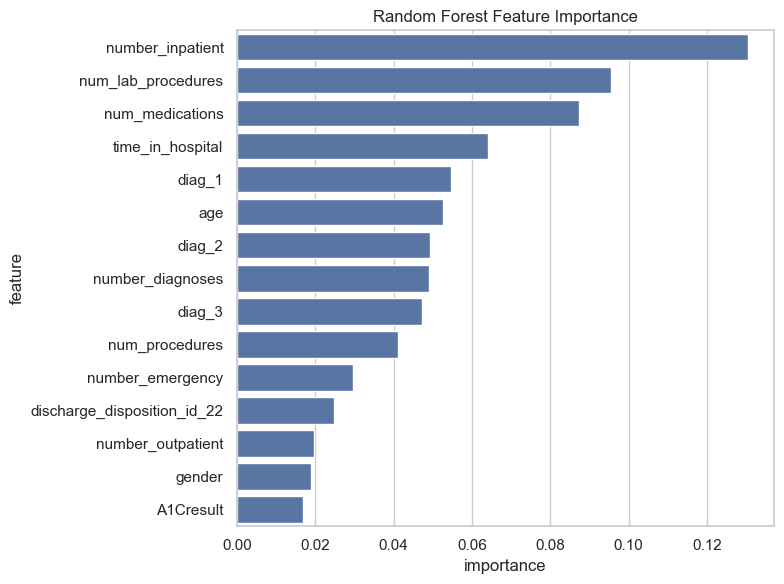


=== MLP Neural Network ===
Accuracy:   0.678
Precision:  0.181
Recall:     0.519
F1-score:   0.268
ROC-AUC:    0.648

Confusion matrix:
 [[12297  5308]
 [ 1089  1174]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.70      0.79     17605
           1       0.18      0.52      0.27      2263

    accuracy                           0.68     19868
   macro avg       0.55      0.61      0.53     19868
weighted avg       0.83      0.68      0.73     19868



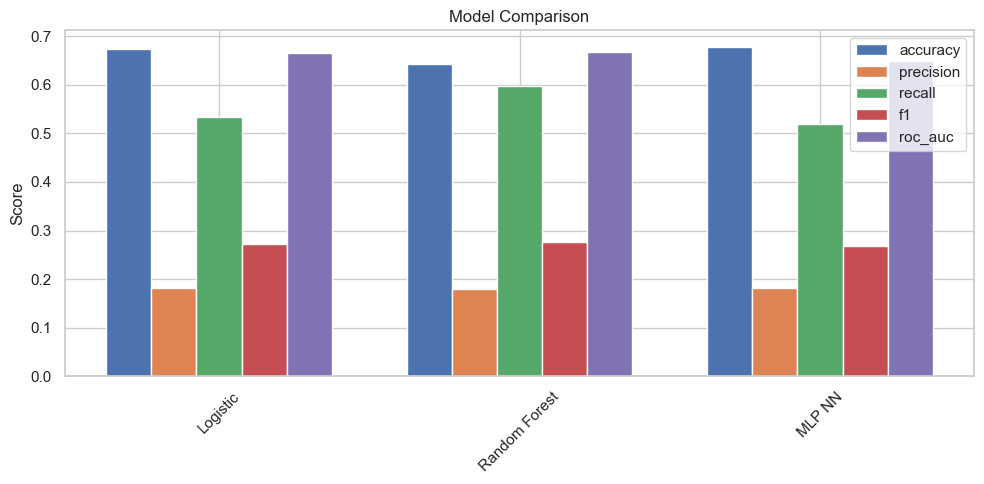

In [12]:
# 5. MODELS: BASELINE + ADVANCED

results = {}

# 5.1 Logistic Regression (baseline)
log_reg = LogisticRegression(
    max_iter=300,
    class_weight='balanced',
    n_jobs=1
)
results["Logistic"] = train_and_evaluate(
    log_reg,
    X_train_bal_scaled, y_train_bal,
    X_test_scaled, y_test,
    name="Logistic Regression (L2, balanced)"
)

# 5.2 Random Forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=1
)
results["Random Forest"] = train_and_evaluate(
    rf,
    X_train_bal, y_train_bal,     # trees don't need scaling
    X_test, y_test,
    name="Random Forest"
)
plot_feature_importance(rf, X_train_bal.columns, "Random Forest Feature Importance")

# # 5.3 SVM with RBF kernel
# svc = SVC(
#     kernel='rbf',
#     C=1.0,
#     gamma='scale',
#     class_weight='balanced',
#     probability=False,
#     random_state=42
# )
# results["SVM (RBF)"] = train_and_evaluate(
#     svc,
#     X_train_bal_scaled, y_train_bal,
#     X_test_scaled, y_test,
#     name="SVM (RBF kernel)"
# )


# 5.4 Neural Network (MLP)
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    alpha=1e-4,             # L2 regularization
    batch_size=256,
    learning_rate_init=1e-3,
    max_iter=50,
    early_stopping=True,
    random_state=42
)
results["MLP NN"] = train_and_evaluate(
    mlp,
    X_train_bal_scaled, y_train_bal,
    X_test_scaled, y_test,
    name="MLP Neural Network"
)

# Overall comparison
plot_model_comparison(results)


In [13]:
from sklearn.svm import SVC

svc = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    class_weight='balanced',
    probability=False,   # 👈 this is key
    random_state=42
)
import numpy as np

# Use at most 20k samples for SVM to keep it tractable
max_svm_samples = 20000
n_train = len(X_train_bal_scaled)

if n_train > max_svm_samples:
    svm_idx = np.random.RandomState(42).choice(
        n_train,
        size=max_svm_samples,
        replace=False
    )
    X_train_svm = X_train_bal_scaled.iloc[svm_idx]
    y_train_svm = y_train_bal.iloc[svm_idx]
else:
    X_train_svm = X_train_bal_scaled
    y_train_svm = y_train_bal

print("SVM training size:", X_train_svm.shape[0])
results["SVM (RBF)"] = train_and_evaluate(
    svc,
    X_train_svm, y_train_svm,
    X_test_scaled, y_test,
    name="SVM (RBF kernel)"
)


SVM training size: 18102

=== SVM (RBF kernel) ===
Accuracy:   0.659
Precision:  0.179
Recall:     0.553
F1-score:   0.270
ROC-AUC:    0.655

Confusion matrix:
 [[11845  5760]
 [ 1011  1252]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.67      0.78     17605
           1       0.18      0.55      0.27      2263

    accuracy                           0.66     19868
   macro avg       0.55      0.61      0.52     19868
weighted avg       0.84      0.66      0.72     19868



6. Cross-Validation & Hyperparameter Tuning (Model Selection)

We’ll do proper CV for Random Forest and SVM to show parameter exploration & complexity control.

In [17]:
# 6. CROSS-VALIDATION & HYPERPARAMETER TUNING

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 6.1 Random Forest tuning
rf_base = RandomForestClassifier(random_state=42, n_jobs=1)

rf_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 5]
}

rf_grid = GridSearchCV(
    rf_base,
    param_grid=rf_param_grid,
    cv=cv,
    scoring="roc_auc",
    n_jobs=1,
    verbose=1
)
rf_grid.fit(X_train_bal, y_train_bal)

print("\nRandom Forest best params:", rf_grid.best_params_)
print("Random Forest best CV ROC-AUC:", rf_grid.best_score_)

# Re-evaluate best RF on test set
best_rf = rf_grid.best_estimator_
rf_tuned_res = train_and_evaluate(
    best_rf,
    X_train_bal, y_train_bal,
    X_test, y_test,
    name="Random Forest (tuned)"
)


Fitting 5 folds for each of 12 candidates, totalling 60 fits

Random Forest best params: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 200}
Random Forest best CV ROC-AUC: 0.6612724891691278

=== Random Forest (tuned) ===
Accuracy:   0.642
Precision:  0.176
Recall:     0.584
F1-score:   0.271
ROC-AUC:    0.667

Confusion matrix:
 [[11436  6169]
 [  942  1321]]

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.65      0.76     17605
           1       0.18      0.58      0.27      2263

    accuracy                           0.64     19868
   macro avg       0.55      0.62      0.52     19868
weighted avg       0.84      0.64      0.71     19868



7. Under- vs Over-Fitting Analysis

We’ll explicitly vary model complexity and compare training vs validation scores.

Here’s an example for a Decision Tree and Random Forest by varying depth:

In [15]:
# 7. UNDER-/OVER-FITTING ANALYSIS

def complexity_curve_decision_tree(X, y, depths, cv):
    train_scores = []
    val_scores   = []

    for d in depths:
        tree = DecisionTreeClassifier(
            max_depth=d,
            random_state=42
        )
        # training score via cross_val_score on full data? Instead:
        # fit on train folds / evaluate both
        cv_train = []
        cv_val   = []
        for train_idx, val_idx in cv.split(X, y):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]

            tree.fit(X_tr, y_tr)

            y_tr_pred = tree.predict(X_tr)
            y_val_pred = tree.predict(X_val)

            cv_train.append(accuracy_score(y_tr, y_tr_pred))
            cv_val.append(accuracy_score(y_val, y_val_pred))

        train_scores.append(np.mean(cv_train))
        val_scores.append(np.mean(cv_val))

    plt.figure(figsize=(6,4))
    plt.plot(depths, train_scores, marker='o', label='Train Accuracy')
    plt.plot(depths, val_scores, marker='o', label='Val Accuracy')
    plt.xlabel("max_depth")
    plt.ylabel("Accuracy")
    plt.title("Decision Tree Complexity Curve")
    plt.legend()
    plt.show()

depths = [3, 5, 10, 20, None]
# For plotting, you might convert None to some label later.
depth_values = [d for d in depths if d is not None]

# Use only finite depths for curve
complexity_curve_decision_tree(X_train_bal, y_train_bal, depth_values, cv)


NameError: name 'cv' is not defined

8. (Optional) Cross-Validated ROC Curves

If you want extra polish:

In [ ]:
from sklearn.metrics import RocCurveDisplay

# Example for best RF
best_rf.fit(X_train_bal, y_train_bal)
y_proba_rf = best_rf.predict_proba(X_test)[:,1]

RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title("ROC Curve - Random Forest (tuned)")
plt.show()
